In [20]:
import glob

import astropy.coordinates as coord
import astropy.units as u
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import sunpy.map
import sunpy.visualization.colormaps
from astropy.coordinates import SkyCoord
from tqdm import tqdm
from sunpy.coordinates.sun import carrington_rotation_time

from sunpy.net import Fido
from sunpy.net import attrs as a
from sunpy.time import TimeRange

In [21]:
datadir = '/Users/clowder/data/aia_rotation/'

In [22]:
def keynote_figs():
    matplotlib.rcParams['lines.color'] = 'white'
    matplotlib.rcParams['patch.edgecolor'] = 'white'
    matplotlib.rcParams['text.color'] = 'white'
    matplotlib.rcParams['axes.facecolor'] = 'black'
    matplotlib.rcParams['axes.edgecolor'] = 'white'
    matplotlib.rcParams['axes.labelcolor'] = 'white'
    matplotlib.rcParams['xtick.color'] = 'white'
    matplotlib.rcParams['ytick.color'] = 'white'
    matplotlib.rcParams['grid.color'] = 'white'
    matplotlib.rcParams['figure.facecolor'] = 'black'
    matplotlib.rcParams['figure.edgecolor'] = 'black'
    matplotlib.rcParams['savefig.facecolor'] = 'black'
    matplotlib.rcParams['savefig.edgecolor'] = 'black'
    matplotlib.rcParams['font.size'] = 10
    matplotlib.rcParams['lines.linewidth'] = 1.5
    matplotlib.rcParams['font.family'] = 'sans-serif'
    matplotlib.rcParams['text.usetex'] = False

keynote_figs()

In [ ]:
cr = 2222

t0 = carrington_rotation_time(cr)
t1 = carrington_rotation_time(cr+1)

result = Fido.search(a.Time(t0, t1), a.Instrument.aia, a.Wavelength(171 * u.angstrom), a.Sample(1*u.day))

In [74]:
result

Start Time,End Time,Source,Instrument,Wavelength,Provider,Physobs,Wavetype,Extent Width,Extent Length,Extent Type,Size
,,,,Angstrom,,,,,,,Mibyte
Time,Time,str3,str3,float64[2],str4,str9,str6,str4,str4,str8,float64
2019-09-19 03:42:45.000,2019-09-19 03:42:46.000,SDO,AIA,171.0 .. 171.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2019-09-20 03:42:45.000,2019-09-20 03:42:46.000,SDO,AIA,171.0 .. 171.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2019-09-21 03:42:45.000,2019-09-21 03:42:46.000,SDO,AIA,171.0 .. 171.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2019-09-22 03:42:45.000,2019-09-22 03:42:46.000,SDO,AIA,171.0 .. 171.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2019-09-23 03:42:45.000,2019-09-23 03:42:46.000,SDO,AIA,171.0 .. 171.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2019-09-24 03:42:45.000,2019-09-24 03:42:46.000,SDO,AIA,171.0 .. 171.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2019-09-25 03:42:45.000,2019-09-25 03:42:46.000,SDO,AIA,171.0 .. 171.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844
2019-09-26 03:42:45.000,2019-09-26 03:42:46.000,SDO,AIA,171.0 .. 171.0,JSOC,intensity,NARROW,4096,4096,FULLDISK,64.64844


In [56]:
files = Fido.fetch(result, path=datadir)

Files Downloaded:   0%|          | 0/28 [00:00<?, ?file/s]


















































































































































































































































































































































































































































































































































































































Files Downloaded:   4%|▎         | 1/28 [00:22<10:10, 22.61s/file]


















































Files Downloaded:   7%|▋         | 2/28 [00:23<04:11,  9.68s/file]






















































Files Downloaded:  11%|█         | 3/28 [00:24<02:28,  5.93s/file]








Files Downloaded:  14%|█▍        |

In [57]:
out_shape=(4096,4096)
block_size=(1024,1024)

map_np = np.full(out_shape, np.nan)
map_sp = np.full(out_shape, np.nan)

for file in tqdm(files):
    aia_map = sunpy.map.Map(file)
    aia_map.data[...] = aia_map.data[...] / aia_map.meta['EXPTIME']

    obs_np = SkyCoord(0*u.deg, 90*u.deg, 1*u.AU, obstime=aia_map.date, frame='heliographic_carrington', observer='self')
    out_ref_coord_np = SkyCoord(0*u.arcsec, 0*u.arcsec, obstime=obs_np.obstime,
                            frame='helioprojective', observer=obs_np,
                            rsun=aia_map.coordinate_frame.rsun)
    out_header_np = sunpy.map.make_fitswcs_header(
        out_shape,
        out_ref_coord_np,
        scale=u.Quantity(aia_map.scale),
        instrument=aia_map.instrument,
        wavelength=aia_map.wavelength
    )
    outmap_np = aia_map.reproject_to(out_header_np, algorithm='adaptive', block_size=block_size, parallel=True)

    obs_sp = SkyCoord(0*u.deg, -90*u.deg, 1*u.AU, obstime=aia_map.date, frame='heliographic_carrington', observer='self')
    out_ref_coord_sp = SkyCoord(0*u.arcsec, 0*u.arcsec, obstime=obs_sp.obstime,
                            frame='helioprojective', observer=obs_sp,
                            rsun=aia_map.coordinate_frame.rsun)
    out_header_sp = sunpy.map.make_fitswcs_header(
        out_shape,
        out_ref_coord_sp,
        scale=u.Quantity(aia_map.scale),
        instrument=aia_map.instrument,
        wavelength=aia_map.wavelength
    )
    outmap_sp = aia_map.reproject_to(out_header_sp, algorithm='adaptive', block_size=block_size, parallel=True)

    map_np = np.fmin(map_np, outmap_np.data*(outmap_np.data!=0))
    map_sp = np.fmin(map_sp, outmap_sp.data*(outmap_sp.data!=0))

  0%|          | 0/28 [00:00<?, ?it/s]2025-04-04 16:56:50 - reproject.common - INFO: Setting up output dask array with map_blocks
2025-04-04 16:56:50 - reproject.common - INFO: Computing output array directly to zarr array at /var/folders/6f/n6wcm_dd6s7b6mqr3h6n18d40000gp/T/tmpytw6dcwd/6c44251e-b1ec-4dc0-a3eb-b3ea9ed622ad.zarr
2025-04-04 16:56:55 - reproject.common - INFO: Copying output zarr array into output Numpy arrays
2025-04-04 16:56:55 - reproject.common - INFO: Setting up output dask array with map_blocks
2025-04-04 16:56:55 - reproject.common - INFO: Computing output array directly to zarr array at /var/folders/6f/n6wcm_dd6s7b6mqr3h6n18d40000gp/T/tmpuutaa2v5/ae9ad72c-ff34-42de-aa85-80470f770a2f.zarr
2025-04-04 16:56:59 - reproject.common - INFO: Copying output zarr array into output Numpy arrays
  4%|▎         | 1/28 [00:09<04:13,  9.37s/it]2025-04-04 16:57:00 - reproject.common - INFO: Setting up output dask array with map_blocks
2025-04-04 16:57:00 - reproject.common - INFO:

In [58]:
cmap = f"sdoaia{aia_map.wavelength.value.astype(int)}"
wavelength = aia_map.wavelength.value.astype(int)

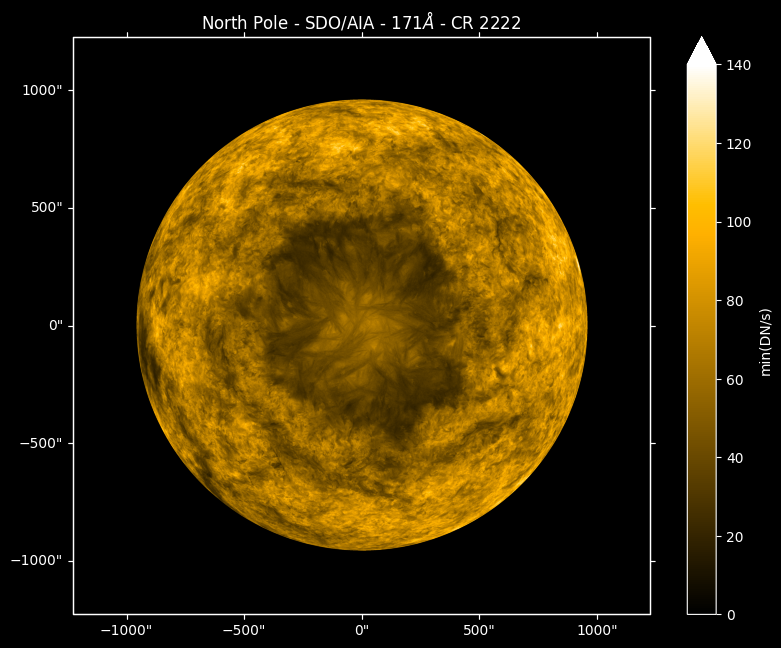

In [67]:
fig, ax = plt.subplots(figsize=(9.5, 7.5), subplot_kw={'projection':outmap_np.wcs})

im = ax.imshow(map_np, cmap=matplotlib.colormaps[cmap], vmin=0, vmax=140)

ax.set_facecolor('black')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title(f"North Pole - SDO/AIA - {wavelength}$\\AA$ - CR {cr}")
fig.colorbar(im, ax=ax, label='min(DN/s)', extend='max')
# outmap_np.draw_grid(axes=ax, color='w', ls='dotted', alpha=0.5)

plt.savefig(f"./plt/cr{cr}-np-{wavelength}A.pdf")

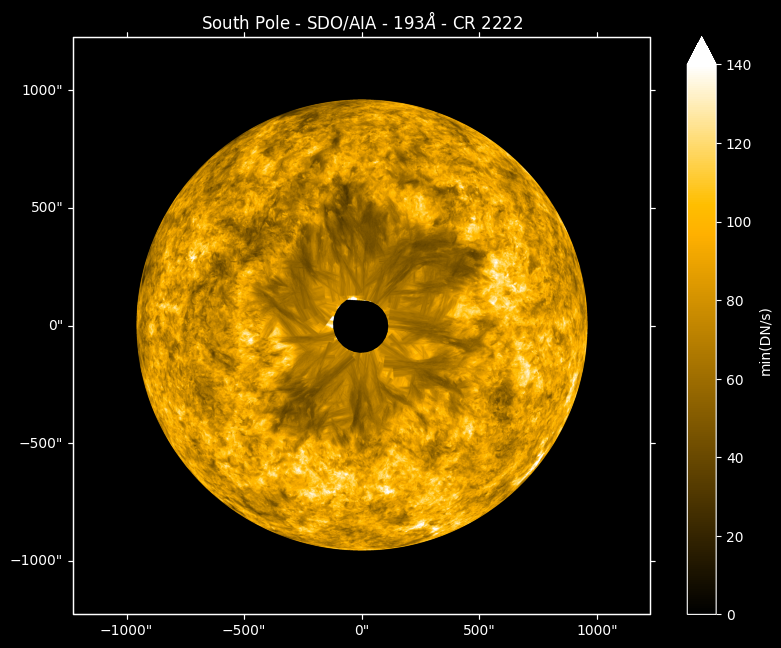

In [68]:
fig, ax = plt.subplots(figsize=(9.5, 7.5), subplot_kw={'projection':outmap_sp.wcs})

im = ax.imshow(map_sp, cmap=matplotlib.colormaps[cmap], vmin=0, vmax=140)

ax.set_facecolor('black')
# ax.coords.grid(color='white', alpha=.25, ls='dotted')
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title(f"South Pole - SDO/AIA - 193$\\AA$ - CR {cr}")
fig.colorbar(im, ax=ax, label='min(DN/s)', extend='max')
# outmap_sp.draw_grid(axes=ax, color='w', ls='dotted', alpha=0.5)

plt.savefig(f"./plt/cr{cr}-sp-{wavelength}A.pdf")